# Marcha 2D de la reducción II.F

Calbuco, conducto cilíndrico, malla de 8 radios. Cada llamada a `marchar(v)` es **un tiro**: integra la columna con esa velocidad de entrada y no la cambia.

El método del tiro, el lazo que mueve `v_in` hasta cerrar la boca, está en `tirar`. Acepta la columna que llega a `z = 0`. Una columna que se pone sónica bajo la superficie es un tiro con su `v_in` dado; ese lazo no la elige.

Antes de fragmentar, el paso es de diferencias finitas. En `z` la derivada va hacia atrás. En `r` el término viscoso es un sistema tridiagonal y lo resuelve Thomas. La viscosidad y el coeficiente de inercia dependen de la velocidad que se está buscando: esa no linealidad se resuelve por Picard, congelando esos coeficientes, resolviendo el sistema lineal y repitiendo. Picard no es otra discretización.

Cuando `φ` pasa `φ_crit` en toda la sección, se dejan el Thomas y el Picard. `u_m(r)` y `u_g(r)` salen de las dos masas con el caudal `q(r)` de cada radio, y `dP/dz` junto con `dφ/dz` salen del momento promediado en la sección. Ese `dφ/dz` es un solo número y se suma igual en todos los radios, así que un `φ` plano sigue plano.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from RIconduit2D_IIF import marchar, tirar

sonico = marchar(18.0, n_r=8)
boca = marchar(10.0, n_r=8)

def resumen(sal):
    dphi = float(np.max(sal["phi"][-1]) - np.min(sal["phi"][-1]))
    print(
        f"v = {sal['vinicial']:.0f} m/s | {sal['mensaje']} | "
        f"z = {sal['z'][-1]:.1f} m | P = {sal['P'][-1] / 1e6:.2f} MPa"
    )
    print(
        f"  fragmenta en z = {sal['z_frag']:.1f} m | "
        f"u_m eje = {sal['um'][-1, 0]:.1f} m/s | "
        f"u_g eje = {sal['ug'][-1, 0]:.1f} m/s"
    )
    print(f"  φ máximo − φ mínimo en el último nivel = {dphi:.3e}")

resumen(sonico)
resumen(boca)


v = 18 m/s | sonico | z = -195.4 m | P = 1.77 MPa
  fragmenta en z = -952.0 m | u_m eje = 430.7 m/s | u_g eje = 833.8 m/s
  φ máximo − φ mínimo en el último nivel = 4.745e-05
v = 10 m/s | boca | z = 0.0 m | P = 11.19 MPa
  fragmenta en z = -367.5 m | u_m eje = 69.1 m/s | u_g eje = 72.2 m/s
  φ máximo − φ mínimo en el último nivel = 1.349e-04


La figura de abajo tiene `P`, las dos velocidades en el eje y `φ`. `φ` usa escala lineal de 0 a 1. La curva de `u_g` se separa de `u_m` recién después de fragmentar.


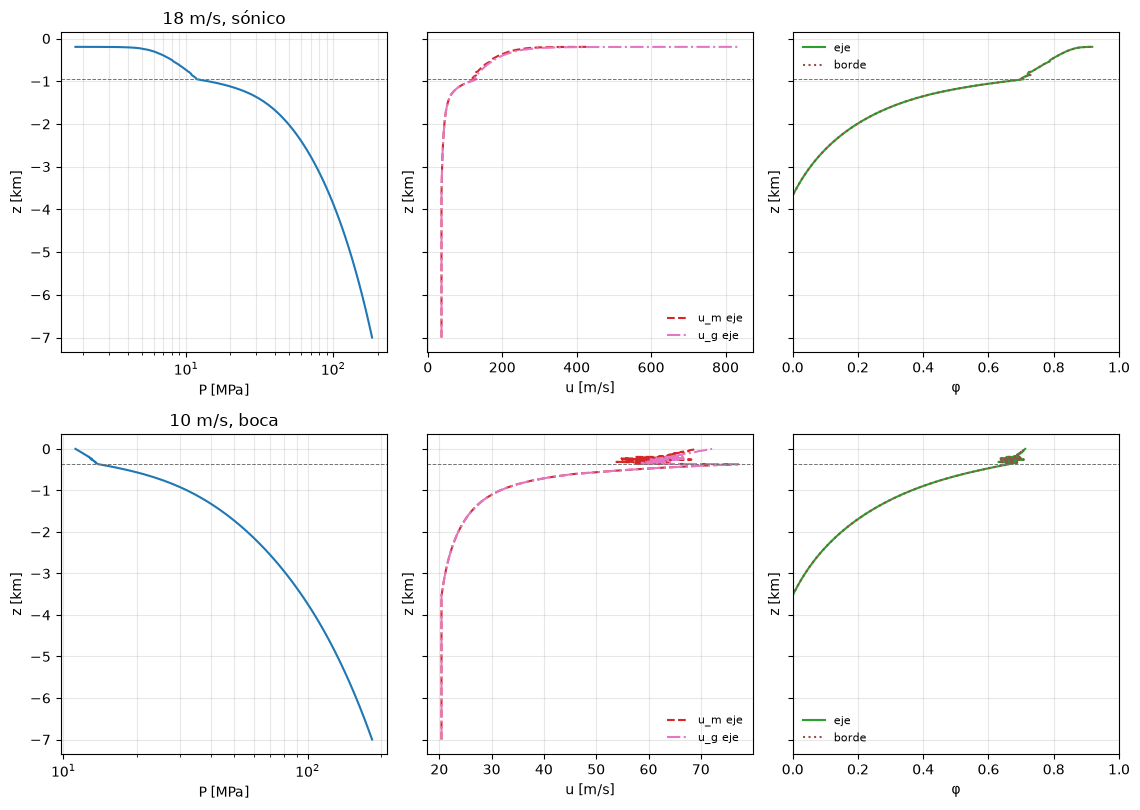

In [2]:
def columna(sal, ejes, titulo):
    z = sal["z"] / 1000.0
    ejes[0].plot(sal["P"] / 1e6, z, color="C0")
    ejes[0].set_xscale("log")
    ejes[0].set_xlabel("P [MPa]")
    ejes[1].plot(sal["um"][:, 0], z, color="C3", ls="--", label="u_m eje")
    ejes[1].plot(sal["ug"][:, 0], z, color="C6", ls="-.", label="u_g eje")
    ejes[1].set_xlabel("u [m/s]")
    ejes[1].legend(frameon=False, fontsize=8)
    ejes[2].plot(sal["phi"][:, 0], z, color="C2", label="eje")
    ejes[2].plot(sal["phi"][:, -1], z, color="C5", ls=":", label="borde")
    ejes[2].set_xlim(0.0, 1.0)
    ejes[2].set_xlabel("φ")
    ejes[2].legend(frameon=False, fontsize=8)
    for ax in ejes:
        ax.axhline(sal["z_frag"] / 1000.0, color="0.45", lw=0.7, ls="--")
        ax.grid(True, which="both", alpha=0.3)
        ax.set_ylabel("z [km]")
    ejes[0].set_title(titulo)

fig, ejes = plt.subplots(2, 3, figsize=(11.5, 8.2), sharey="row")
columna(sonico, ejes[0], "18 m/s, sónico")
columna(boca, ejes[1], "10 m/s, boca")
fig.tight_layout()
plt.show()


`φ` en el último nivel, contra `r`, en la escala de 0 a 1.
La diferencia entre el eje y el borde es del orden de 10⁻⁴: entra solo por `ξ`, que pasa de 0.250 a 0.251. En la escala de la fracción las dos curvas son horizontales.


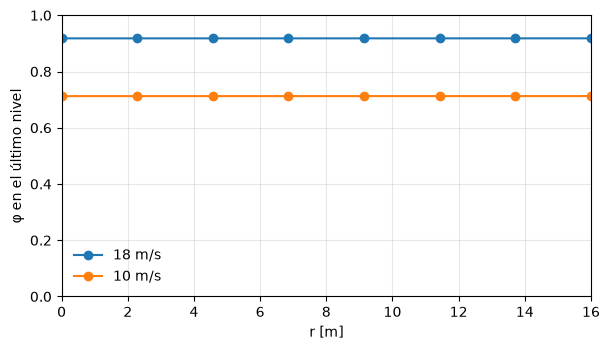

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
for sal, nombre in ((sonico, "18 m/s"), (boca, "10 m/s")):
    ax.plot(sal["r"], sal["phi"][-1], marker="o", label=nombre)
ax.set_xlabel("r [m]")
ax.set_ylabel("φ en el último nivel")
ax.set_xlim(0, sal["r"][-1])
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


`tirar` repite la marcha y se queda con el mayor `v_in` que llega a `z = 0`. Con la malla de 8 radios ese valor queda por debajo del tiro sónico de 17.5 m/s, que se corta a unos 16 m de la boca.


In [4]:
tiro = tirar(v_min=12.0, v_max=20.0, n_tiro=5, n_r=8)
print(
    f"tiro aceptado: v = {tiro['vinicial']:.2f} m/s | {tiro['mensaje']} | "
    f"z = {tiro['z'][-1]:.1f} m | P = {tiro['P'][-1] / 1e6:.2f} MPa"
)


tiro aceptado: v = 17.25 m/s | boca | z = 0.0 m | P = 4.89 MPa
